In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('D:\LEARNING\\train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Why do EDA
    • Model Building 
    • Analysis and Reporting
    • validate assumptions
    • Handling missing values
    • Feature(Columns) Engineering 
    • Detecting Outliers

In [3]:
# Remember it is an iterative process...

### Columns Types :
    • Numerical -> Age, Fare, PassengerId
    • Categorical -> Survived, Pclass, Sex, SibSp, Parch, Embarked
    • Mixed -> Name, Ticket, Cabin

## Univariate Analysis :

###  *Univariate analysis focuses on analyzing each feature in the dataset independently*.
    • Distribution analysis: The distribution of each feature is examined to identify its shape, central tendency,and dispersion.
    • Identifying Potential issues : Univariate analysis helps in identifying potential problems with the data such as outlier, skewness, and missing values.

### *The shape of a data distribution refers to its overall pattern or form as it is represented on a graph. Some common shapes of data distributions include*:
    • Normal Distribution: A symmetrical and bell-shaped distribution where the mean, median and mode are equal and the majority of the data falls in the middle of the distribution with gradually decreasing frequencies towards the tails.
    • Skewed Distribution: A distribution that is not symmetrical, with one tail begin longer than the other. It can be either positively skewed (right-skewed) or Negatively skewed (left-skewed).
    • Bimodal Distribution: A distribution with two peaks or modes, indicating the presence of two distinct groups or clusters within the data.
    • Uniform Distribution: A distribution where all values have an equal chance of occurring.

*The shape of the data distribution is important in identifying the presence of outliers, skewness and type of statistical tests and models that can be used for further analysis.*

*Dispersion is a statistical term used to describe the spread or variability of a set of data. It measures how far the values in a dataset are spread out from the central tendency(Mean , Median, Mode) of the dataset.*

### There are several measures of dispersion, including: 
    • Range: The difference between the largest and smallest values in a dataset.
    • Variance: The average of the squared deviations of each value from the mean of the dataset.
    • Standard Deviation: The square root of the variance. It provides a measure fo the spread of the data that is in the same units as the original data.

    • Interquartile Range (IQR): The range between the first quartile (25th percentile) and the third quartile (75th percentile) of the data.

*Dispersion helps to describe the spread of the data, which can help to identify the presence of outliers, and skewness in the data.*

## *Steps of doing Univariate Analysis on Numerical Columns* :-

    • Descriptive Statistics: Compute basic summary statistics for the column, such as mean, median, mode , standard deviation, range, and quartiles. these statistics give a general understanding of the distribution of the data and and can help identify skewness or outliers.

    • Visualization: Create visualizations to explore the distribution of the data, Some common visualizations for numerical data include histograms, box plot, and density plot. these visualizations provide a visual representation of the distribution of the data and can help identify skewness an outliers.

    • Identifying Outliers: Identify and examine any outliers in the data. Outliers can be Identified using visualizations. It is important to determine whether the outlier are due to measurement errors, data entry errors or legitimate differences in the data and decide whether to include or exclude them from the analysis.

    • Skewness: Check for skewness in the data and consider transforming the data or using robust statistical methods that are less sensitive to skewness if necessary.

    • Conclusion: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.

# Age :-


### Conclusion :
    - Age is normally(almost) distributed 
    - 20% of the values are missing 
    - There are some outliers in the data (Age > 65).

In [4]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

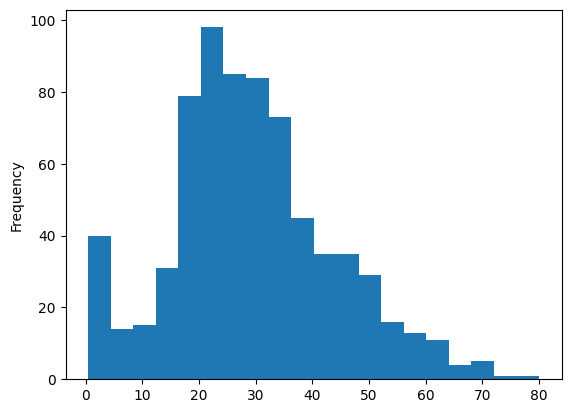

In [7]:
df['Age'].plot(kind='hist', bins=20)

<Axes: ylabel='Density'>

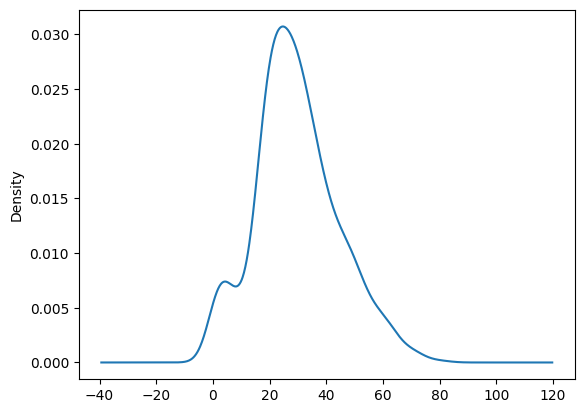

In [9]:
df['Age'].plot(kind='kde')

In [10]:
df['Age'].skew() # almost Normal skewed.

np.float64(0.38910778230082704)

<Axes: >

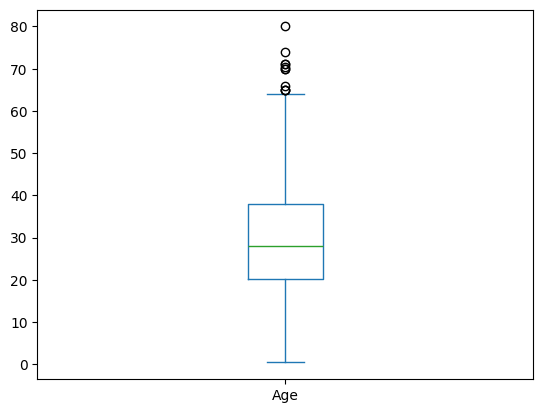

In [11]:
df['Age'].plot(kind='box')

In [12]:
# analyze the outliers

df[df['Age'] > 65]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [ ]:
df['Age'].isnull().sum()/len(df) # almost 20% of the data is missing in the Age column.

np.float64(0.19865319865319866)

# Fare Column :-

### Conclusion :
    - The data Fare is highly positively skewed.
    - Fare columns actually contains the group fare and not the individual fare.(this might be and issue)
    - We need to create new columns called individual fare.

In [15]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: ylabel='Frequency'>

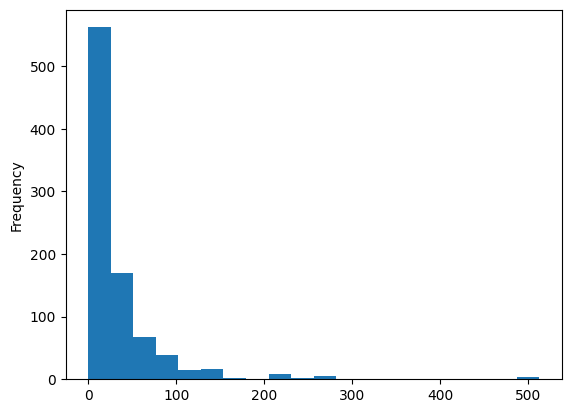

In [16]:
df['Fare'].plot(kind='hist', bins=20)

<Axes: ylabel='Density'>

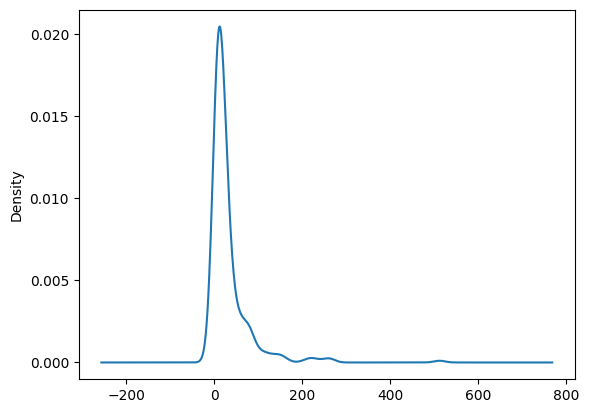

In [17]:
df['Fare'].plot(kind='kde')

In [ ]:
df['Fare'].skew() # highly Positive skewed data.

np.float64(4.787316519674893)

<Axes: >

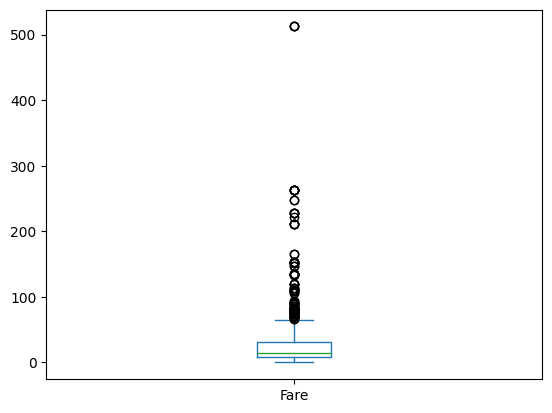

In [19]:
df['Fare'].plot(kind='box')

In [22]:
df[df['Fare'] > 250] 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [23]:
df['Fare'].isnull().sum()

np.int64(0)

## *Steps of doing Univariate Analysis on Categorical Columns*

    • Descriptive Statistics: Compute the frequency distribution of the categories in the columns. this will give a general understanding of the distribution of the categories adn their relative fequencies.

    • Visualization: Create visualizations to explore the distribution of the categories. Some common visualizations for categorical data include count plots adn piw charts. these visualizations provide a visual representation of the distribution of the categories and can help identify any patterns or anomalies in the data.

    • Missing Values: Check for missing values in the data and decide how to handle them. Missing values can be imputed or excluded from the analysis, depending on the research questions and the dataset.

    Conclusion: Summarize the findings of the EDA and make decisions about how to process with further analysis.
